In [25]:
# Put import statements here
import os
# hide tensorflow info/warning logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import sys
import subprocess
from pathlib import Path
import json
import pandas as pd


# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
import src.data_preprocessing.image_data_exploration as img_explore
from src.agents.Visual_Agent import VisualModel
from src.util.logger import Logger
import src.config as config
import src.util.general as general_util
from src.data_preprocessing.TextTokenizer import TextTokenizer
from src.data_preprocessing.TextEmbedder import TextEmbedder
import src.evaluation.visual_evaluator as visual_evaluator
from src.data_preprocessing.USDA_processing import embed_USDA_data, make_USDA_plant_sheets_dataframe
import json
from src.util.logger import Logger


17:38:12 [WARNING ]: USDA Json Breakdown Description:
       symbol                     scientific_name     rank  group  \
count    1915                                1915     1915   1915   
unique   1915                                1915        1      5   
top      ZOTE  Zoysia tenuifolia Willd. ex Thiele  Species  Dicot   
freq        1                                   1     1915   1126   

                    common_name other_common_names    durations growth_habits  \
count                      1908               1915         1915          1915   
unique                     1905                 84            8            19   
top     zarzabacoa de dos hojas                 []  [Perennial]   [Forb/herb]   
freq                          2               1832         1505           809   

       fact_sheet_urls plant_guide_urls  \
count             1915             1915   
unique              88              173   
top                 []               []   
freq              1828

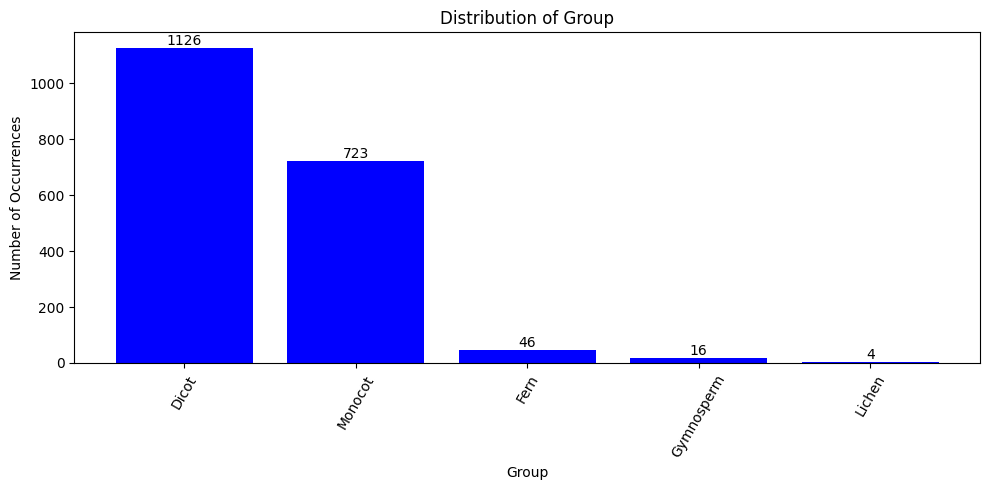

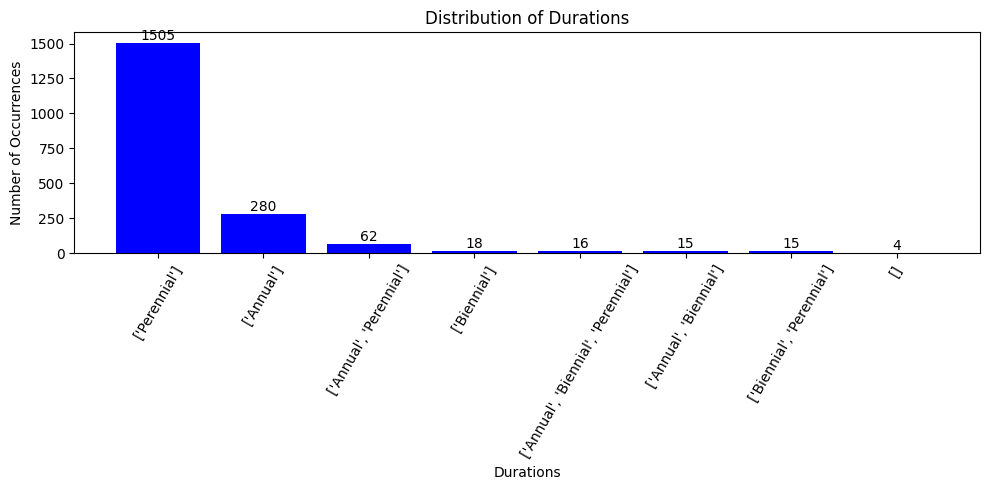

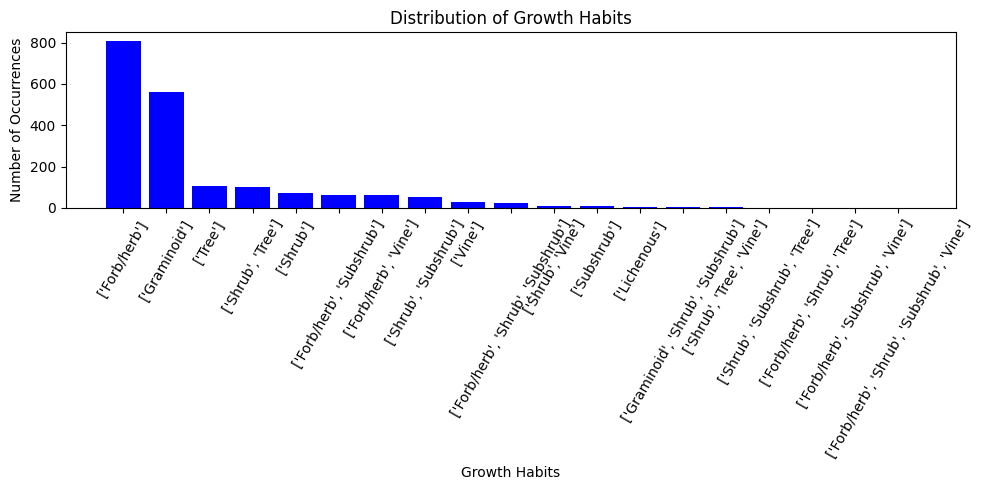

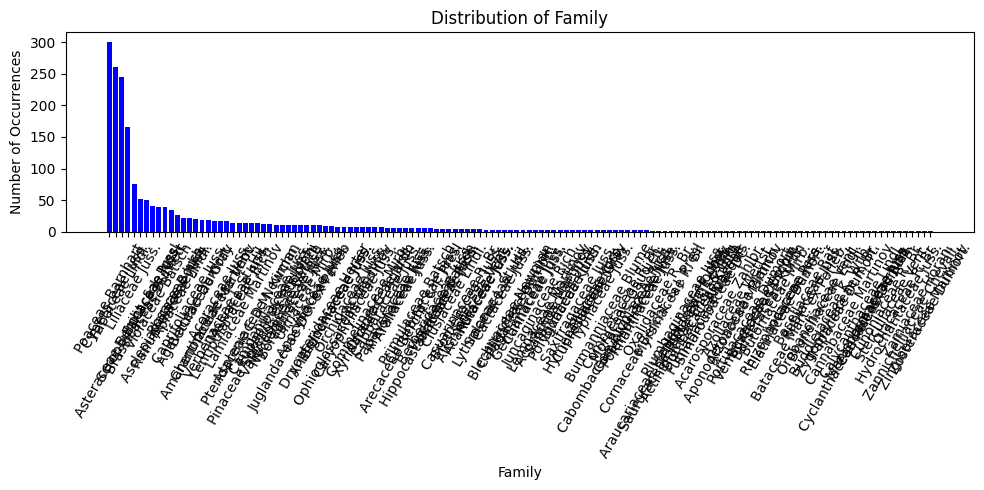

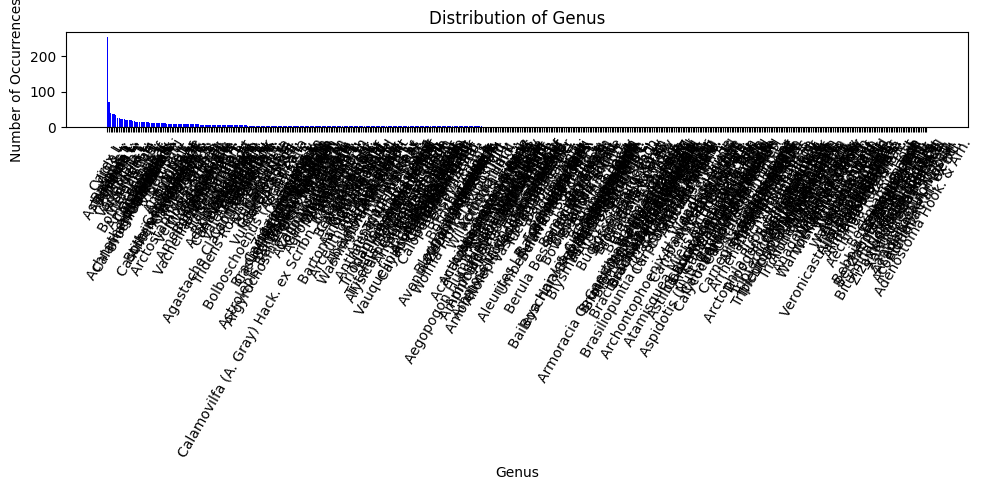

In [ ]:
# Load USDA text data
kb = config.Data.USDA.JSON_FILES
kb_list = []
for item in kb.iterdir():
    with open(item, 'r') as jfile:
        data = json.load(jfile)
        kb_list.append(data)

kb_df = pd.DataFrame(kb_list)
description = kb_df.describe()
#only using warning logger as the info logger is not legible with my vscode color scheme! 
Logger.warning(f"{'USDA Json Breakdown'} Description:\n{description}")
column_distribution_args= [
    {"column": "group", "show_counts": True, "figure_size": (10, 5)},
    {"column": "durations", "show_counts": True, "figure_size": (10, 5)},
    {"column": "growth_habits", "show_counts": False, "figure_size": (10, 5)},
    #{"column": "native_regions", "show_counts": False, "figure_size": (10, 5)},
    {"column": "family", "show_counts": False, "figure_size": (10, 5)},
    {"column": "genus", "show_counts": False, "figure_size": (10, 5)},
]

text_explore.make_column_distributions(kb_df, column_distribution_args)


--------------------- USDA Plant Sheets Text Data Exploration ---------------------------

In [ ]:
# Load USDA text data

usda_plant_sheets= make_USDA_plant_sheets_dataframe(config.Data.USDA.PLANT_SHEETS)

In [ ]:
# explore USDA text data
print(len(usda_plant_sheets))
# When we embed the USDA data, we won't actually preprocess/clean the text very much
# But for the sake of exploring, cleaning and normalization can help us find patterns by removing some noise
text_pre.preprocess_dataframe(
    usda_plant_sheets,
    ["text"],
    [],
    {},
    [],
    "",
)

# explore the cleaned training dataset
text_explore.explore_data(
    usda_plant_sheets, 
    [], 
    ["text"], 
    top_n_words=20, 
    name="USDA Plant Sheets Dataset"
)

--------------------- PlantExpertVQA Data Exploration ---------------------------

In [14]:
# preprocess (not tokenize) the training, testing, and validation datasets

plant_expert_vqa_TRAIN= text_pre.load_csv(config.Data.PlantExpertVQA.TRAIN_FILE)
plant_expert_vqa_TEST= text_pre.load_csv(config.Data.PlantExpertVQA.TEST_FILE)
plant_expert_vqa_VAL= text_pre.load_csv(config.Data.PlantExpertVQA.VALIDATION_FILE)

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    config.Data.PlantExpertVQA.TEXT_COLUMNS,
    config.Data.PlantExpertVQA.COLUMNS_TO_REMOVE,
    config.Data.PlantExpertVQA.NA_FILL,
    ["image_path"],
    config.Data.PlantExpertVQA.ROOT,
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    config.Data.PlantExpertVQA.TEXT_COLUMNS,
    config.Data.PlantExpertVQA.COLUMNS_TO_REMOVE,
    config.Data.PlantExpertVQA.NA_FILL,
    ["image_path"],
    config.Data.PlantExpertVQA.ROOT,
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    config.Data.PlantExpertVQA.TEXT_COLUMNS,
    config.Data.PlantExpertVQA.COLUMNS_TO_REMOVE,
    config.Data.PlantExpertVQA.NA_FILL,
    ["image_path"],
    config.Data.PlantExpertVQA.ROOT,
)


17:22:32 [DEBUG   ]: [load_csv] Successfully loaded C:\Users\Kyler_Code\Desktop\PlantQA\data\PlantExpertVQA\data\train.csv into dataframe


c:\Users\Kyler_Code\Desktop\PlantQA\src\data_preprocessing\text_preprocessing.py:48: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


17:22:32 [DEBUG   ]: [load_csv] Successfully loaded C:\Users\Kyler_Code\Desktop\PlantQA\data\PlantExpertVQA\data\test.csv into dataframe
17:22:32 [DEBUG   ]: [load_csv] Successfully loaded C:\Users\Kyler_Code\Desktop\PlantQA\data\PlantExpertVQA\data\val.csv into dataframe


<class 'pandas.core.frame.DataFrame'>
Index: 532657 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              532657 non-null  object
 1   image_id           532657 non-null  object
 2   image_path         532657 non-null  object
 3   crop               532657 non-null  object
 4   disease            532657 non-null  object
 5   category           532657 non-null  object
 6   severity           532657 non-null  object
 7   question_text      532657 non-null  object
 8   answer             532657 non-null  object
 9   answer_type        532657 non-null  object
 10  question_category  532657 non-null  object
 11  cognitive_level    532657 non-null  object
dtypes: object(12)
memory usage: 52.8+ MB
17:22:40 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



17:22:41 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                       qa_i

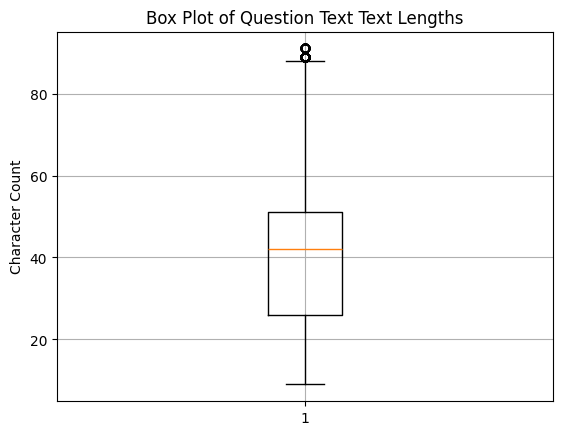







17:22:41 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Class Frequency Distributions --------




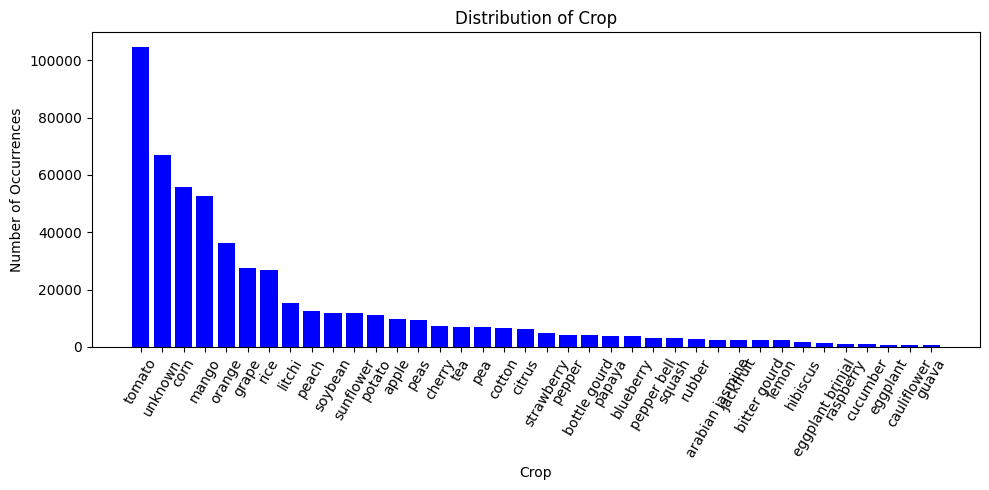

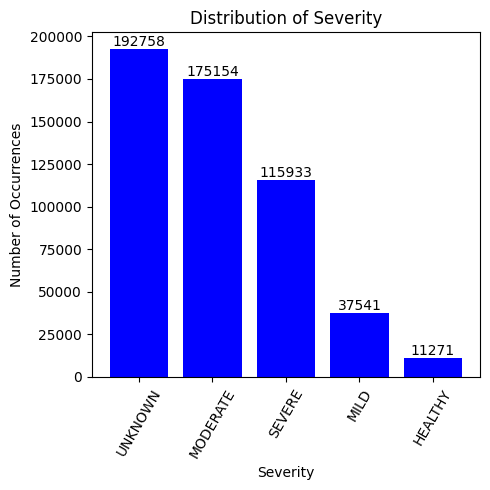

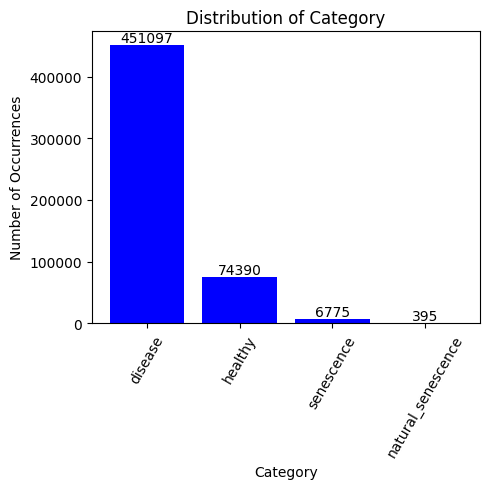

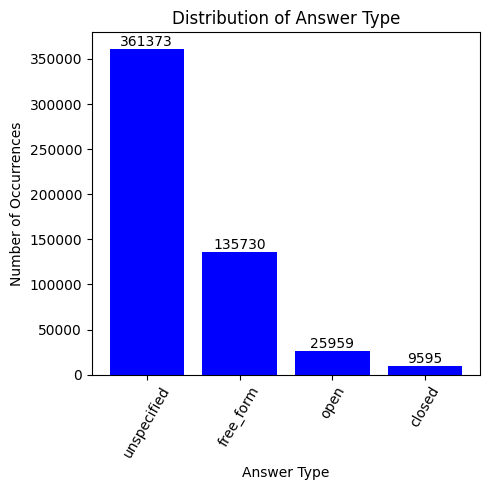

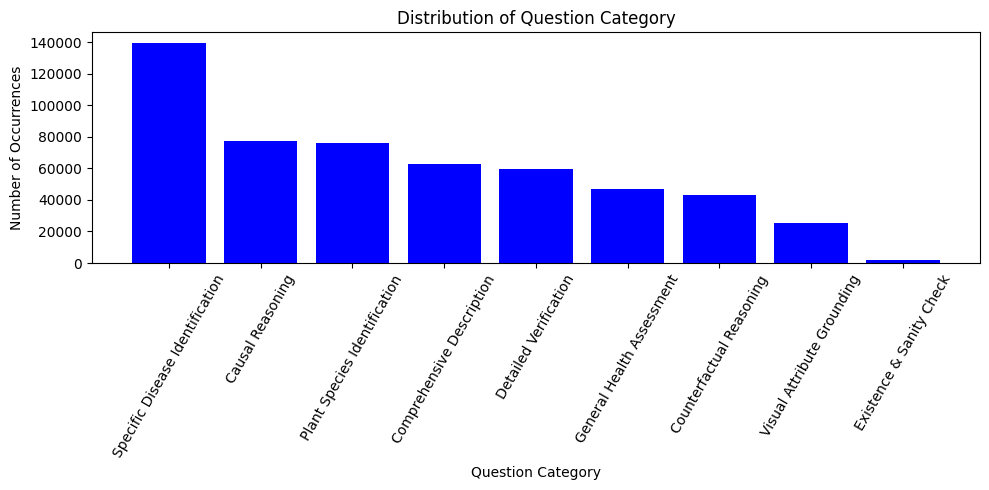







17:22:41 [INFO    ]: 

-------- Plant Expert VQA Training Dataset WordClouds --------




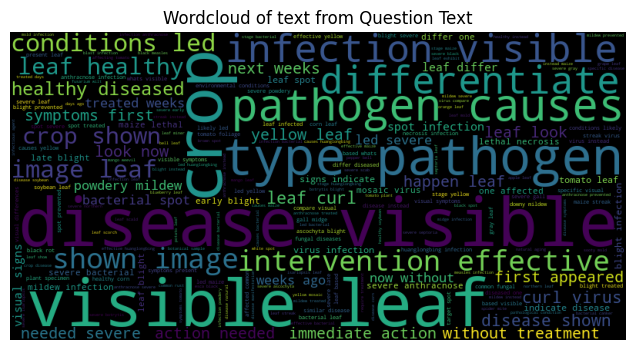







17:22:44 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Word Frequency Distributions --------




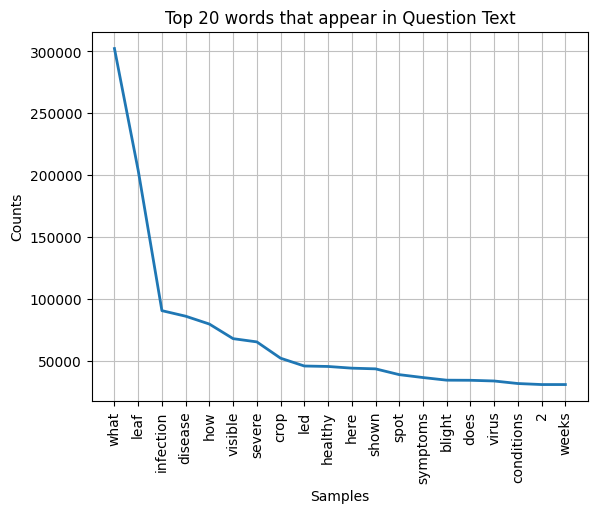

In [15]:

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    config.Data.PlantExpertVQA.TEXT_COLUMNS, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [ ]:
# Most of the images are a small photo pasted onto a large blank canvas, so we crop before resizing
img_explore.show_padding(plant_expert_vqa_TRAIN, config.Data.PlantExpertVQA, count=8)

# The cropped image next to the two channels the mask branch receives
img_explore.show_cropped_and_mask(plant_expert_vqa_TRAIN, config.Data.PlantExpertVQA, count=3)

In [ ]:
traits = ["crop", "disease", "severity"]

classes = {}
for t in traits:
    names = sorted(plant_expert_vqa_TRAIN[t].unique())  # adds names of plants
    classes[t] = names + ["unknown"]  # adds unknown species

train_img = VisualModel.one_row_per_image(plant_expert_vqa_TRAIN, traits)
val_img = VisualModel.one_row_per_image(plant_expert_vqa_VAL, traits)
test_img = VisualModel.one_row_per_image(plant_expert_vqa_TEST, traits)
classes = VisualModel.build_classes(train_img, traits)

train_ds = VisualModel.make_dataset(train_img, classes, config.Data.PlantExpertVQA.ROOT, training=True)
val_ds = VisualModel.make_dataset(val_img, classes, config.Data.PlantExpertVQA.ROOT)

# every image shows up once per question, and those rows do not always agree on a label
img_explore.show_labels(plant_expert_vqa_TRAIN, traits)

------------------ LeafBranch Data Exploration -------------------

In [ ]:
# Load the leafbranch csv files

leafbranch_frames= []

for file in config.Data.LeafBranch.CSV.iterdir():
    if not general_util.is_csv(file):
        Logger.warning(f"Non CSV file found: {file}")
        continue

    frame= text_pre.load_csv(file)
    leafbranch_frames.append(frame)

leafbranch= pd.concat(leafbranch_frames, ignore_index=True)

In [ ]:
# clean the leafbranch data
text_pre.preprocess_dataframe(
    leafbranch,
    config.Data.LeafBranch.TEXT_COLUMNS,
    config.Data.LeafBranch.COLUMNS_TO_REMOVE,
    config.Data.LeafBranch.NA_FILL,
    [],
    config.Data.LeafBranch.ROOT,
)

In [ ]:

column_distribution_args= [
    {"column": "answer", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_type", "show_counts": True, "figure_size": (5, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    leafbranch, 
    column_distribution_args, 
    config.Data.LeafBranch.TEXT_COLUMNS, 
    top_n_words=20, 
    name="LeafBranch Dataset"
)